# **EDA on piezometer data**

In [1]:
# Import libraries
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Loading the dataframe
input_path = Path("..") / 'data' / 'external' / 'piezometre_data.csv'
df = pd.read_csv(input_path)
display(df.head(5))
print("Shape of the piezometer dataframe:\n", df.shape)

,Unnamed: 0,code_bss,bss_id,urn_bss,date_mesure,timestamp_mesure,niveau_nappe_eau,mode_obtention,statut,qualification,code_continuite,nom_continuite,code_producteur,nom_producteur,code_nature_mesure,nom_nature_mesure,profondeur_nappe
0,0,10906X0039/C2-1,BSS002MNYD,http://services.ades.eaufrance.fr/pointeau/109...,2000-04-14,955670400000,102.31,Valeur mesurée,Donnée contrôlée niveau 1,Correcte,2,Point lié au point précédent,231,Bureau de Recherches Géologiques et Minières (...,NaN,NaN,4.85
1,1,10906X0039/C2-1,BSS002MNYD,http://services.ades.eaufrance.fr/pointeau/109...,2000-04-15,955756800000,102.29,Valeur mesurée,Donnée contrôlée niveau 1,Correcte,2,Point lié au point précédent,231,Bureau de Recherches Géologiques et Minières (...,NaN,NaN,4.87
2,2,10906X0039/C2-1,BSS002MNYD,http://services.ades.eaufrance.fr/pointeau/109...,2000-04-16,955843200000,102.28,Valeur mesurée,Donnée contrôlée niveau 1,Correcte,2,Point lié au point précédent,231,Bureau de Recherches Géologiques et Minières (...,NaN,NaN,4.88
3,3,10906X0039/C2-1,BSS002MNYD,http://services.ades.eaufrance.fr/pointeau/109...,2000-04-17,955929600000,102.29,Valeur mesurée,Donnée contrôlée niveau 1,Correcte,2,Point lié au point précédent,231,Bureau de Recherches Géologiques et Minières (...,NaN,NaN,4.87
4,4,10906X0039/C2-1,BSS002MNYD,http://services.ades.eaufrance.fr/pointeau/109...,2000-04-18,956016000000,102.31,Valeur mesurée,Donnée contrôlée niveau 1,Correcte,2,Point lié au point précédent,231,Bureau de Recherches Géologiques et Minières (...,NaN,NaN,4.85


Shape of the piezometer dataframe:
 (8851, 17)


8851 rows and 17 columns

In [3]:
df.describe()

,Unnamed: 0,timestamp_mesure,niveau_nappe_eau,code_continuite,code_producteur,profondeur_nappe
count,8851.00000,8.851000e+03,8851.000000,8851.000000,8.851000e+03,8851.000000
mean,4425.00000,1.379904e+12,103.236502,1.997062,1.171034e+13,3.923498
std,2555.20795,2.414339e+11,0.978735,0.054122,9.854149e+12,0.978735
min,0.00000,9.556704e+11,100.060000,1.000000,2.310000e+02,2.210000
25%,2212.50000,1.159186e+12,102.560000,2.000000,2.310000e+02,3.120000
50%,4425.00000,1.392075e+12,103.450000,2.000000,2.000158e+13,3.710000
75%,6637.50000,1.587010e+12,104.040000,2.000000,2.000158e+13,4.600000
max,8850.00000,1.784419e+12,104.950000,2.000000,2.000158e+13,7.100000


In [4]:
df["date_mesure"] = pd.to_datetime(df["date_mesure"])
df["date_mesure"].describe()

count                             8851
mean     2013-09-22 21:43:30.010168576
min                2000-04-14 00:00:00
25%                2006-09-25 12:00:00
50%                2014-02-10 00:00:00
75%                2020-04-15 12:00:00
max                2026-07-19 00:00:00
Name: date_mesure, dtype: object

In [5]:
df.columns.tolist()

['Unnamed: 0',
 'code_bss',
 'bss_id',
 'urn_bss',
 'date_mesure',
 'timestamp_mesure',
 'niveau_nappe_eau',
 'mode_obtention',
 'statut',
 'qualification',
 'code_continuite',
 'nom_continuite',
 'code_producteur',
 'nom_producteur',
 'code_nature_mesure',
 'nom_nature_mesure',
 'profondeur_nappe']

In [6]:
df.value_counts()

Unnamed: 0  code_bss         bss_id      urn_bss                                                     date_mesure  timestamp_mesure  niveau_nappe_eau  mode_obtention  statut                     qualification  code_continuite  nom_continuite                code_producteur  nom_producteur                                                                                                        code_nature_mesure  nom_nature_mesure  profondeur_nappe
8850        10906X0039/C2-1  BSS002MNYD  http://services.ades.eaufrance.fr/pointeau/10906X0039/C2-1  2026-07-19   1784419200000     103.84            Valeur mesurée  Donnée brute               Non qualifié   2                Point lié au point précédent  20001584000016   Syndicat Mixte pour la Protection et la Gestion des Nappes Souterraines de la Plaine du Roussillon  (20001584000016)  N                   Naturel            3.32                1
1404        10906X0039/C2-1  BSS002MNYD  http://services.ades.eaufrance.fr/pointeau/10906X0039/C2-1  20

In [7]:
df['mode_obtention'].value_counts()

mode_obtention
Valeur mesurée         7629
Valeur reconstituée    1222
Name: count, dtype: int64

In [8]:
df['date_mesure']

0      2000-04-14
1      2000-04-15
2      2000-04-16
3      2000-04-17
4      2000-04-18
          ...    
8846   2026-07-15
8847   2026-07-16
8848   2026-07-17
8849   2026-07-18
8850   2026-07-19
Name: date_mesure, Length: 8851, dtype: datetime64[ns]

In [9]:
# Evaluation of the datatype per columns
df.dtypes

Unnamed: 0                     int64
code_bss                      object
bss_id                        object
urn_bss                       object
date_mesure           datetime64[ns]
timestamp_mesure               int64
niveau_nappe_eau             float64
mode_obtention                object
statut                        object
qualification                 object
code_continuite                int64
nom_continuite                object
code_producteur                int64
nom_producteur                object
code_nature_mesure            object
nom_nature_mesure             object
profondeur_nappe             float64
dtype: object

In [10]:
# Number and percentage of NaN
print("Number of NaN per columns:\n", df.isnull().sum())
percent_nan = (df.isnull().sum() / df.shape[0]) / 100
print("\nPercentage of NaN per columns:\n", round(percent_nan, 4))

Number of NaN per columns:
 Unnamed: 0               0
code_bss                 0
bss_id                   0
urn_bss                  0
date_mesure              0
timestamp_mesure         0
niveau_nappe_eau         0
mode_obtention           0
statut                   0
qualification            0
code_continuite          0
nom_continuite           0
code_producteur          0
nom_producteur           0
code_nature_mesure    1439
nom_nature_mesure     1439
profondeur_nappe         0
dtype: int64

Percentage of NaN per columns:
 Unnamed: 0            0.0000
code_bss              0.0000
bss_id                0.0000
urn_bss               0.0000
date_mesure           0.0000
timestamp_mesure      0.0000
niveau_nappe_eau      0.0000
mode_obtention        0.0000
statut                0.0000
qualification         0.0000
code_continuite       0.0000
nom_continuite        0.0000
code_producteur       0.0000
nom_producteur        0.0000
code_nature_mesure    0.0016
nom_nature_mesure     0.0016
pro

## Investigation of the columns code_nature_mesure & nom_nature_mesure
As there is 1439 NaN on those columns, we will look at the type of data in it

In [11]:
print(df[['code_nature_mesure', 'nom_nature_mesure']].value_counts())

code_nature_mesure  nom_nature_mesure
N                   Naturel              7412
Name: count, dtype: int64


In [12]:
# Regarding the contains of those two columns (useless), they will be dropped. 
columns_to_drop = ['code_nature_mesure', 'nom_nature_mesure', 'Unnamed: 0', 'urn_bss', 'timestamp_mesure', 
                   'statut', 'qualification', 'code_continuite', 'nom_continuite', 'code_producteur']

print("Shape of the dataframe before dropping columns:", df.shape)
df_drop = df.drop(columns=columns_to_drop)
print("\nShape of the dataframe after dropping columns:", df_drop.shape)

Shape of the dataframe before dropping columns: (8851, 17)

Shape of the dataframe after dropping columns: (8851, 7)


In [13]:
df_drop.isnull().sum()

code_bss            0
bss_id              0
date_mesure         0
niveau_nappe_eau    0
mode_obtention      0
nom_producteur      0
profondeur_nappe    0
dtype: int64

In [14]:
df_drop.rename(columns={'date_mesure': 'date_index'})

,code_bss,bss_id,date_index,niveau_nappe_eau,mode_obtention,nom_producteur,profondeur_nappe
0,10906X0039/C2-1,BSS002MNYD,2000-04-14,102.31,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...,4.85
1,10906X0039/C2-1,BSS002MNYD,2000-04-15,102.29,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...,4.87
2,10906X0039/C2-1,BSS002MNYD,2000-04-16,102.28,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...,4.88
3,10906X0039/C2-1,BSS002MNYD,2000-04-17,102.29,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...,4.87
4,10906X0039/C2-1,BSS002MNYD,2000-04-18,102.31,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...,4.85
...,...,...,...,...,...,...,...
8846,10906X0039/C2-1,BSS002MNYD,2026-07-15,103.85,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...,3.31
8847,10906X0039/C2-1,BSS002MNYD,2026-07-16,103.84,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...,3.32
8848,10906X0039/C2-1,BSS002MNYD,2026-07-17,103.86,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...,3.30
8849,10906X0039/C2-1,BSS002MNYD,2026-07-18,103.87,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...,3.29


In [15]:
display(df_drop.head(5))

,code_bss,bss_id,date_mesure,niveau_nappe_eau,mode_obtention,nom_producteur,profondeur_nappe
0,10906X0039/C2-1,BSS002MNYD,2000-04-14,102.31,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...,4.85
1,10906X0039/C2-1,BSS002MNYD,2000-04-15,102.29,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...,4.87
2,10906X0039/C2-1,BSS002MNYD,2000-04-16,102.28,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...,4.88
3,10906X0039/C2-1,BSS002MNYD,2000-04-17,102.29,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...,4.87
4,10906X0039/C2-1,BSS002MNYD,2000-04-18,102.31,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...,4.85


In [16]:
print(df_drop['nom_producteur'].value_counts())

nom_producteur
Syndicat Mixte pour la Protection et la Gestion des Nappes Souterraines de la Plaine du Roussillon  (20001584000016)    5182
Bureau de Recherches Géologiques et Minières (231)                                                                      3669
Name: count, dtype: int64


In [17]:
df_drop.describe()

,date_mesure,niveau_nappe_eau,profondeur_nappe
count,8851,8851.000000,8851.000000
mean,2013-09-22 21:43:30.010168576,103.236502,3.923498
min,2000-04-14 00:00:00,100.060000,2.210000
25%,2006-09-25 12:00:00,102.560000,3.120000
50%,2014-02-10 00:00:00,103.450000,3.710000
75%,2020-04-15 12:00:00,104.040000,4.600000
max,2026-07-19 00:00:00,104.950000,7.100000
std,NaN,0.978735,0.978735


# Visulization of the 'niveau_nappe_eau' against 'prodondeur_nappe'

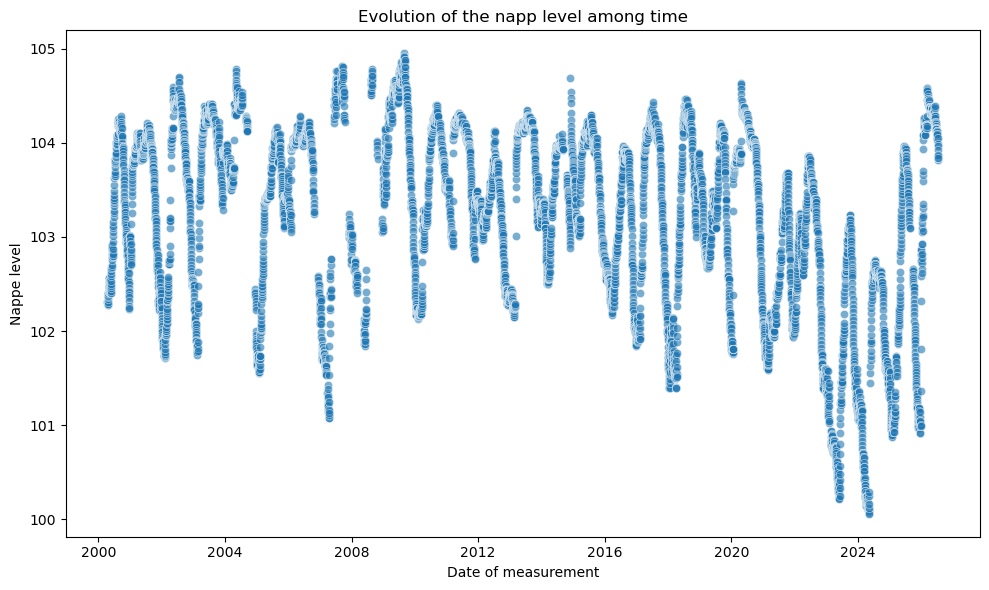

In [18]:
x = df_drop["date_mesure"]
y = df_drop["niveau_nappe_eau"]

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(x, y, alpha=0.6, edgecolors="white", linewidth=0.5)

ax.set_xlabel("Date of measurement")
ax.set_ylabel("Nappe level")
ax.set_title("Evolution of the napp level among time")

plt.tight_layout()
plt.show()

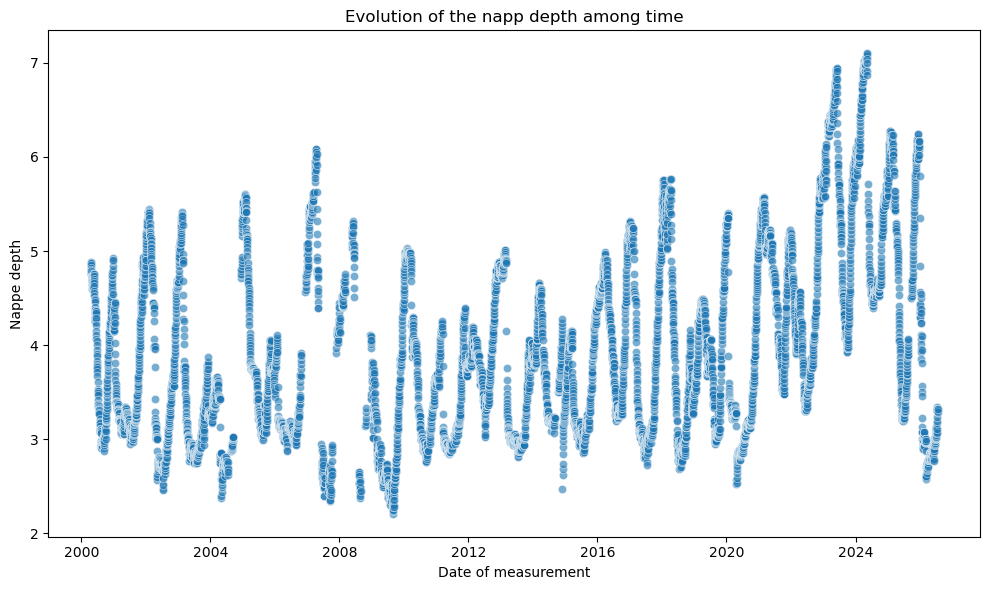

In [19]:
x = df_drop["date_mesure"]
y = df_drop["profondeur_nappe"]

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(x, y, alpha=0.6, edgecolors="white", linewidth=0.5)

ax.set_xlabel("Date of measurement")
ax.set_ylabel("Nappe depth")
ax.set_title("Evolution of the napp depth among time")

plt.tight_layout()
plt.show()

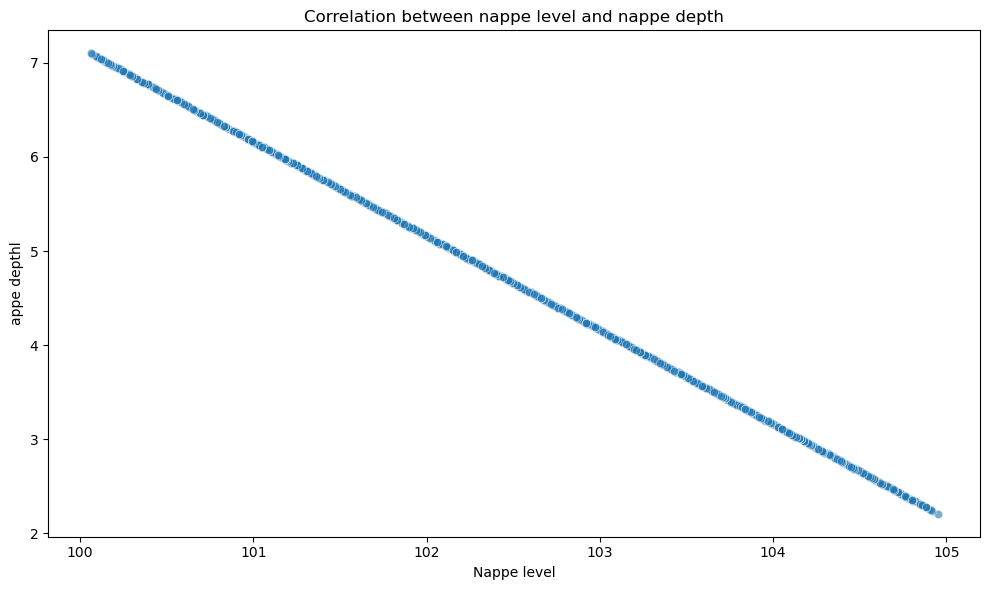

In [20]:
x = df_drop["niveau_nappe_eau"]
y = df_drop["profondeur_nappe"]

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(x, y, alpha=0.6, edgecolors="white", linewidth=0.5)

ax.set_xlabel("Nappe level")
ax.set_ylabel("appe depthl")
ax.set_title("Correlation between nappe level and nappe depth")

plt.tight_layout()
plt.show()

In [21]:
df_drop[["niveau_nappe_eau", "profondeur_nappe"]].corr()

,niveau_nappe_eau,profondeur_nappe
niveau_nappe_eau,1.0,-1.0
profondeur_nappe,-1.0,1.0


Because 'niveau_nappe_eau' and 'profondeur_nappe' are fully correlated, we took the decision to drop the nappe depth.

In [22]:
df_drop = df_drop.drop(columns=['profondeur_nappe'])

# Final checkup of the dataframe before export

In [23]:
print("Number of NaN per columns:\n", df_drop.isnull().sum())
print

Number of NaN per columns:
 code_bss            0
bss_id              0
date_mesure         0
niveau_nappe_eau    0
mode_obtention      0
nom_producteur      0
dtype: int64


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [24]:
display(df_drop)

,code_bss,bss_id,date_mesure,niveau_nappe_eau,mode_obtention,nom_producteur
0,10906X0039/C2-1,BSS002MNYD,2000-04-14,102.31,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...
1,10906X0039/C2-1,BSS002MNYD,2000-04-15,102.29,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...
2,10906X0039/C2-1,BSS002MNYD,2000-04-16,102.28,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...
3,10906X0039/C2-1,BSS002MNYD,2000-04-17,102.29,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...
4,10906X0039/C2-1,BSS002MNYD,2000-04-18,102.31,Valeur mesurée,Bureau de Recherches Géologiques et Minières (...
...,...,...,...,...,...,...
8846,10906X0039/C2-1,BSS002MNYD,2026-07-15,103.85,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...
8847,10906X0039/C2-1,BSS002MNYD,2026-07-16,103.84,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...
8848,10906X0039/C2-1,BSS002MNYD,2026-07-17,103.86,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...
8849,10906X0039/C2-1,BSS002MNYD,2026-07-18,103.87,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...


# Saving the cleaned dataframe into .\data\raw

In [25]:
output_path = Path('..') / 'data' / 'interim' / 'piezometer_cleaned.csv'

df_drop.to_csv(output_path)